In [27]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ==========================================================
# Project Paths
# ==========================================================
PROJECT_ROOT = Path.cwd().parents[2]

PREPROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "preprocessed_data.csv"

LOGRETURN_PATH = PROJECT_ROOT / "data" / "results" / "log_returns.csv"

OUTPUT_FOLDER = (
    PROJECT_ROOT
    / "src"
    / "analysis"
    / "eda"
    / "report"
    / "stationarity_plots"
)

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Load Data
# ==========================================================

price_df = pd.read_csv(PREPROCESSED_PATH)
log_df = pd.read_csv(LOGRETURN_PATH)

price_df["Date"] = pd.to_datetime(price_df["Date"])
log_df["Date"] = pd.to_datetime(log_df["Date"])

# ==========================================================
# Commodity Columns
# ==========================================================

# commodities = [c for c in price_df.columns if c != "Date"]
commodities = [
    "Brent_Oil",
    "Natural_Gas",
    "Gold",
    "Silver",
    "platinum",
    "Palladium",
    "Oats",
    "RBOB_Gasoline"
]
summary = []

for commodity in commodities:

    log_col = commodity + "_logret"

    # Skip if column not found
    if commodity not in price_df.columns:
        print(f"{commodity} not found in original dataset.")
        continue

    if log_col not in log_df.columns:
        print(f"{log_col} not found in log-return dataset.")
        continue

    # -------------------------------
    # Original Price Series
    # -------------------------------

    original = price_df[commodity].dropna()

    adf_before = adfuller(original, autolag="AIC")[1]

    try:
        kpss_before = kpss(original, regression="c", nlags="auto")[1]
    except:
        kpss_before = None

    before_status = (
        "Stationary"
        if adf_before < 0.05 and (kpss_before is None or kpss_before > 0.05)
        else "Non-Stationary"
    )

    # -------------------------------
    # Log Return Series
    # -------------------------------

    transformed = log_df[log_col].dropna()

    adf_after = adfuller(transformed, autolag="AIC")[1]

    try:
        kpss_after = kpss(transformed, regression="c", nlags="auto")[1]
    except:
        kpss_after = None

    after_status = (
        "Stationary"
        if adf_after < 0.05 and (kpss_after is None or kpss_after > 0.05)
        else "Non-Stationary"
    )

    summary.append({
        "Commodity": commodity,
        "ADF_Before": adf_before,
        "KPSS_Before": kpss_before,
        "Before_Status": before_status,
        "ADF_After": adf_after,
        "KPSS_After": kpss_after,
        "After_Status": after_status
    })

    # =====================================================
    # Plot
    # =====================================================

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # ---------- Original ----------
    ax[0].plot(
        price_df["Date"],
        price_df[commodity],
        color="blue",
        linewidth=1
    )

    ax[0].set_title(f"{commodity} (Original Price)")
    ax[0].set_xlabel("Year")
    ax[0].set_ylabel("Price")

    ax[0].xaxis.set_major_locator(mdates.YearLocator(5))
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax[0].text(
        0.02,
        0.98,
        f"ADF p = {adf_before:.6e}\n"
        f"KPSS p = {kpss_before:.6f}\n"
        f"Status = {before_status}",
        transform=ax[0].transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.9)
    )

    # ---------- Log Return ----------
    ax[1].plot(
        log_df["Date"],
        log_df[log_col],
        color="red",
        linewidth=0.8
    )

    ax[1].set_title(f"{commodity} (Log Return)")
    ax[1].set_xlabel("Year")
    ax[1].set_ylabel("Log Return")

    ax[1].xaxis.set_major_locator(mdates.YearLocator(5))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax[1].text(
        0.02,
        0.98,
        f"ADF p = {adf_after:.6e}\n"
        f"KPSS p = {kpss_after:.6f}\n"
        f"Status = {after_status}",
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.9)
    )

    plt.suptitle(
        f"{commodity}: Stationarity Before vs After Log Return",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_FOLDER,
            f"{commodity}_stationarity.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ==========================================================
# Save CSV Summary
# ==========================================================

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    OUTPUT_FOLDER / "stationarity_before_after_summary.csv",
    index=False
)

print("=" * 60)
print("Done!")
print(f"Plots saved to: {OUTPUT_FOLDER}")
print("Summary CSV created.")
print("=" * 60)

Done!
Plots saved to: d:\COLLAGE\DAIICT\Minor-Project\Modeling-Relationship-Between-Commodity-Price-and-Currency-Exchange\src\analysis\eda\report\stationarity_plots
Summary CSV created.


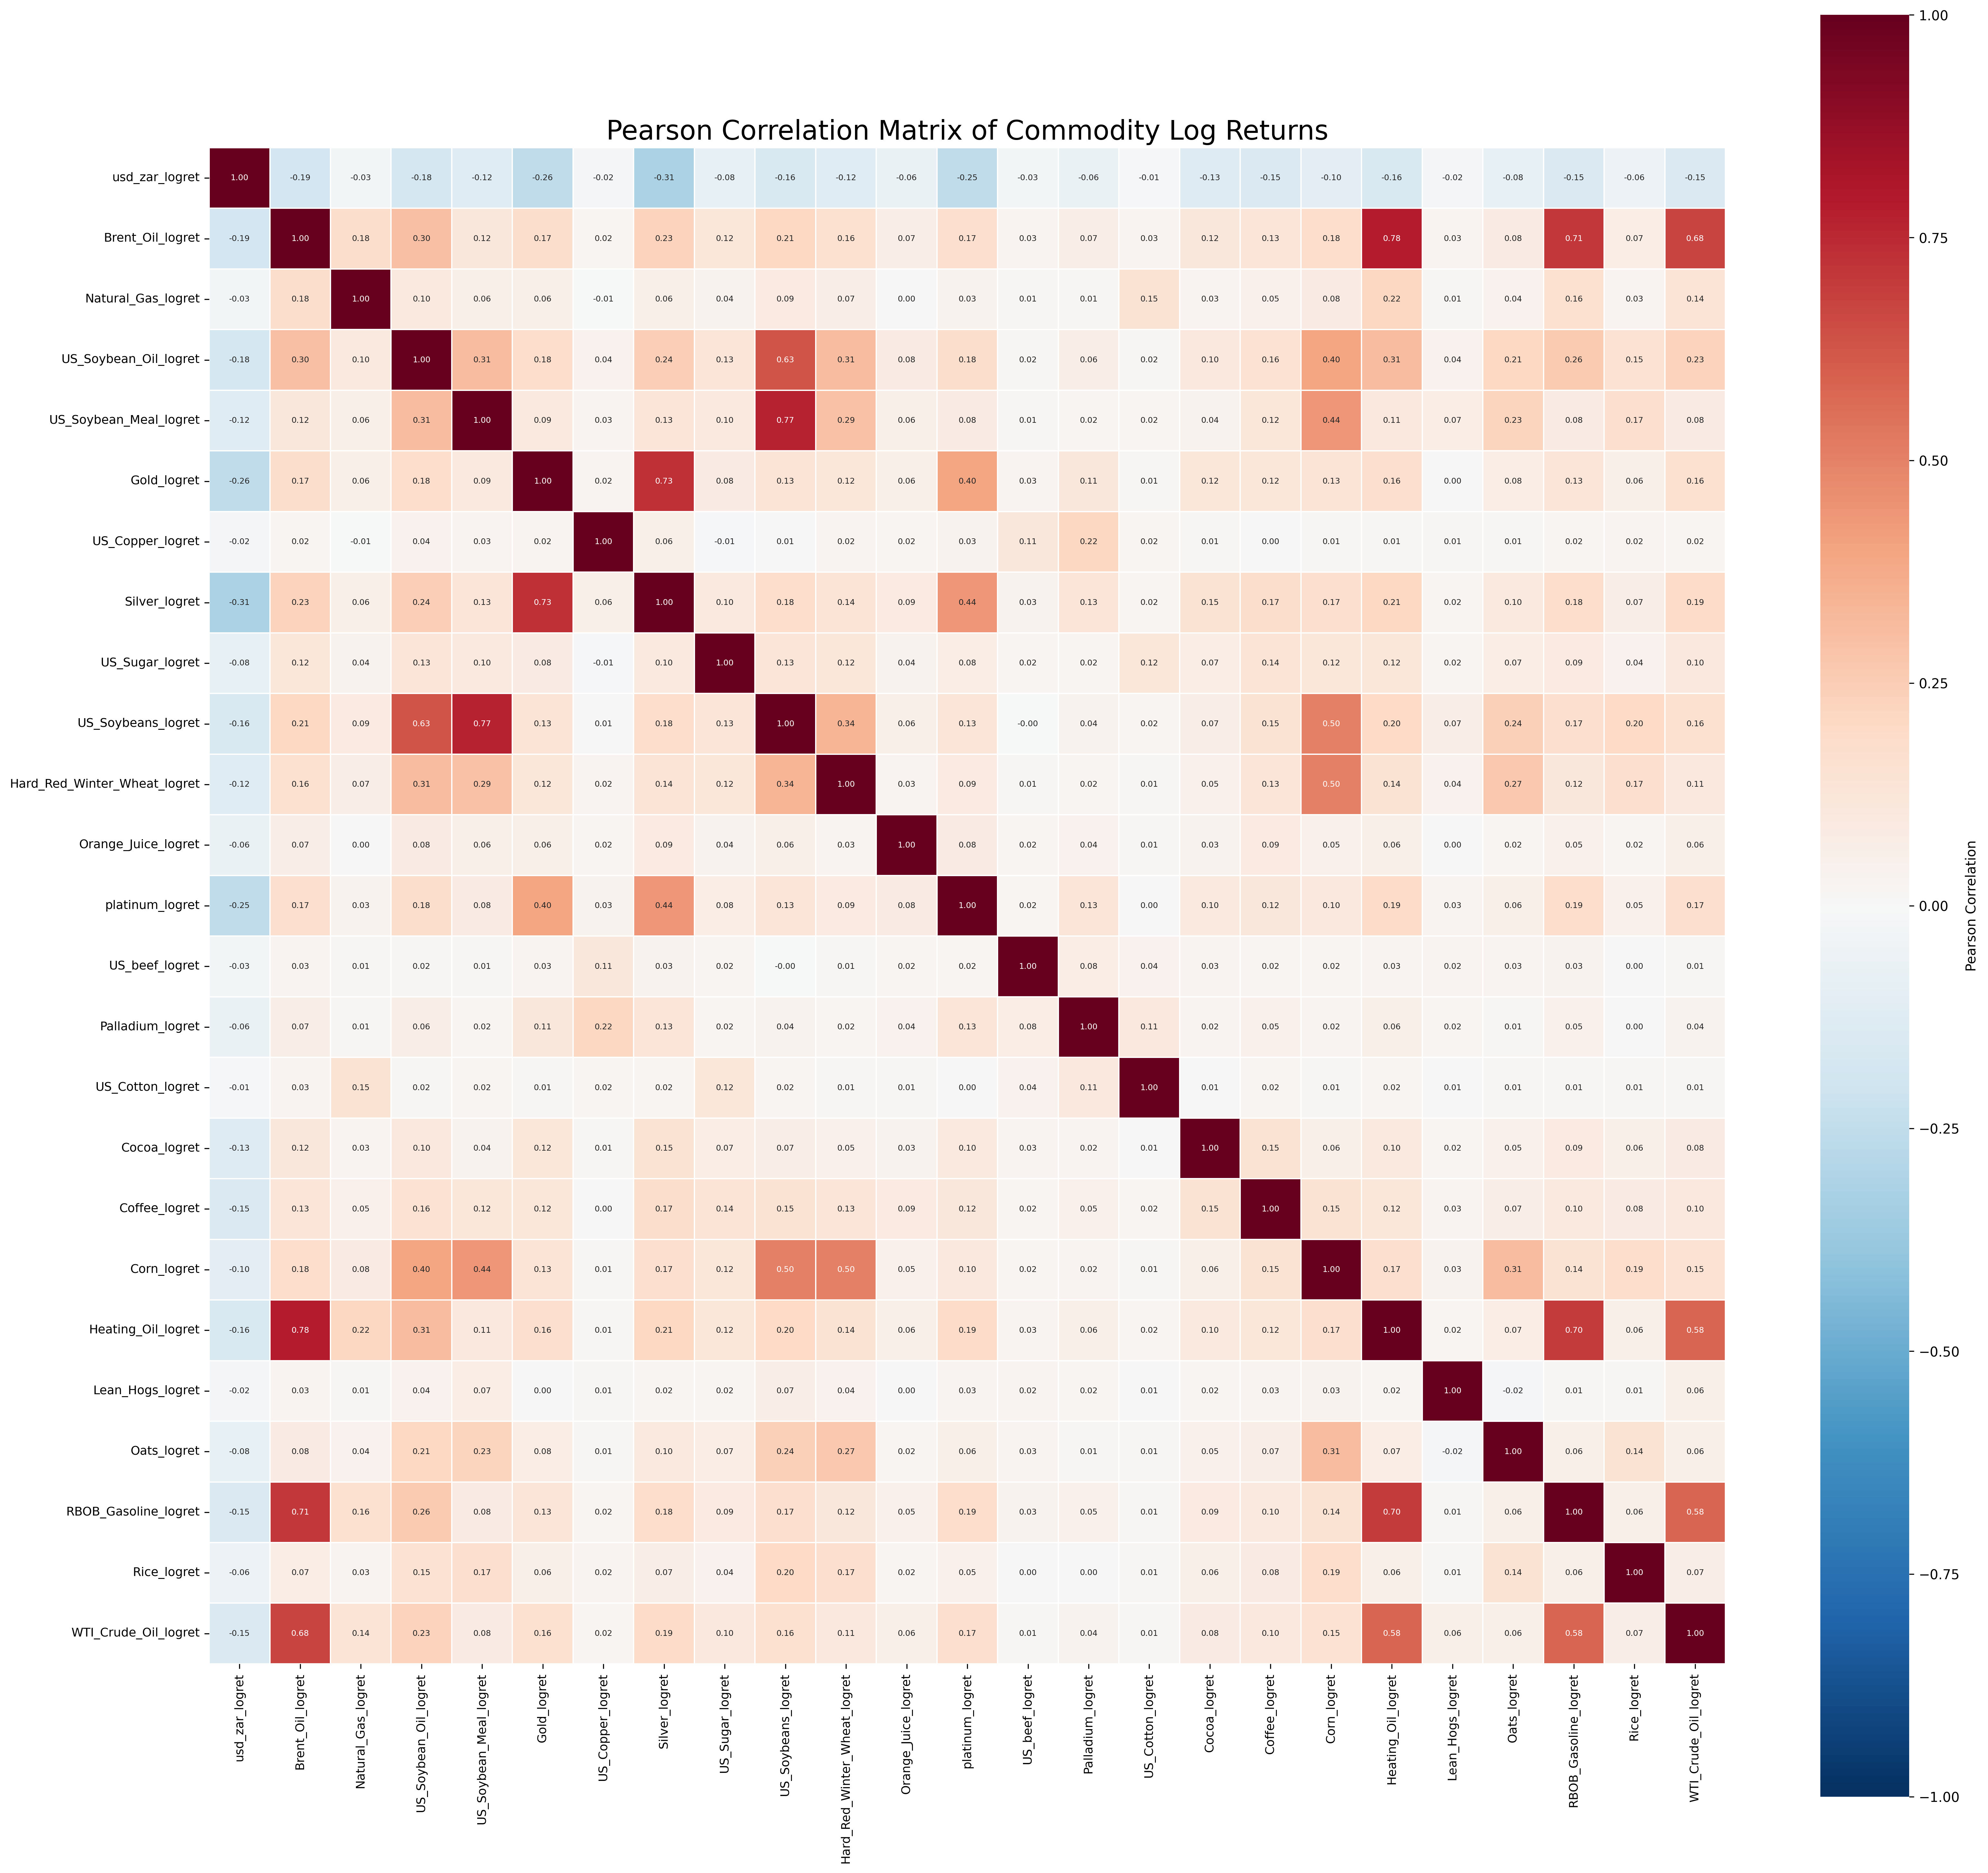

In [29]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 

PROJECT_ROOT = Path.cwd().parents[2]

LOGRETURN_PATH = PROJECT_ROOT / "data" / "results" / "log_returns.csv"
 

df = pd.read_csv(LOGRETURN_PATH)
 

corr = df.drop(columns="Date").corr()

plt.figure(figsize=(22, 20), dpi=300)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Pearson Correlation"},
    annot_kws={"size": 6}
)

plt.title("Pearson Correlation Matrix of Commodity Log Returns", fontsize=20)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

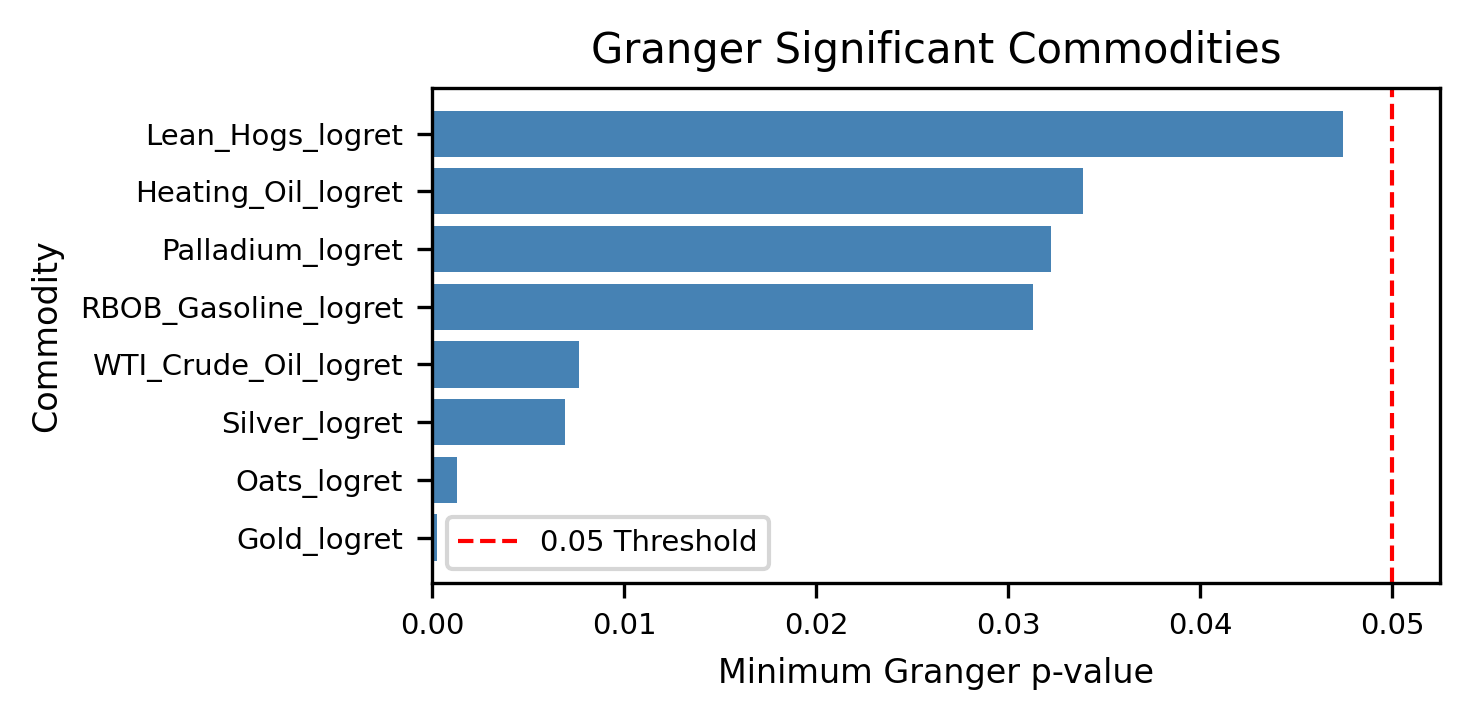

In [34]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Project Paths
# ==========================================================

PROJECT_ROOT = Path.cwd().parents[2]

GRANGER_PATH = PROJECT_ROOT / "data" / "results" / "correlation_granger_analysis.csv"

# ==========================================================
# Load Data
# ==========================================================

df = pd.read_csv(GRANGER_PATH)

# Keep only Granger Significant commodities
df = df[df["Granger_Significant"] == "Yes"].copy()

# Sort by p-value (smallest first)
df = df.sort_values("Granger_min_p")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(5, 2.5), dpi=300)

plt.barh(
    df["Commodity"],
    df["Granger_min_p"],
    color="steelblue"
)

plt.axvline(
    x=0.05,
    color="red",
    linestyle="--",
    linewidth=1,
    label="0.05 Threshold"
)

plt.xlabel("Minimum Granger p-value", fontsize=8)
plt.ylabel("Commodity", fontsize=8)
plt.title("Granger Significant Commodities", fontsize=10)

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.legend(fontsize=7)

plt.tight_layout()
plt.show()